# CAPSTONE PROJECT: BOOKS RECOMMENDER SYSTEM


# Data Preparation

Need to upload data/10000_reviews.csv and data/book_titles.csv to run

In this notebook, we will Load, Clean and merge the csv files - Prepare the data for the next step




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import ast

## Load the Datasets

In [3]:
reviews_raw_df = pd.read_csv('../data/10000_reviews.csv')
book_names_df = pd.read_csv('../data/book_titles.csv')

In [4]:
# Users reviews information
reviews_raw_df.describe()

,Unnamed: 0,book_id,rating,n_votes,n_comments
count,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,6.910120e+05,1.337530e+07,3.695800,3.050500,0.939200
std,3.985966e+05,9.243475e+06,1.232321,12.915968,5.122336
min,1.400000e+01,1.000000e+00,0.000000,0.000000,0.000000
25%,3.525825e+05,6.357565e+06,3.000000,0.000000,0.000000
50%,6.938655e+05,1.333094e+07,4.000000,0.000000,0.000000
75%,1.036109e+06,2.035973e+07,5.000000,2.000000,0.000000
max,1.377876e+06,3.625277e+07,5.000000,444.000000,287.000000


In [5]:
# Book titles information
book_names_df.describe()

,Unnamed: 0,text_reviews_count,average_rating,num_pages,publication_day,publication_month,publication_year,book_id,ratings_count,work_id
count,6301.000000,6301.000000,6301.000000,5968.000000,5362.000000,5505.000000,5622.000000,6.301000e+03,6.301000e+03,6.301000e+03
mean,3150.000000,2652.332804,3.972349,346.728887,14.029280,6.303724,2011.162220,1.393600e+07,5.144573e+04,2.112064e+07
std,1819.086355,6319.195025,0.274742,144.932054,9.772724,3.274454,5.550981,9.537153e+06,1.955803e+05,1.618190e+07
min,0.000000,20.000000,2.460000,1.000000,1.000000,1.000000,1950.000000,1.000000e+00,4.200000e+01,1.140000e+02
25%,1575.000000,332.000000,3.810000,274.000000,5.000000,4.000000,2010.000000,6.492981e+06,2.561000e+03,6.405906e+06
50%,3150.000000,825.000000,3.990000,336.000000,13.000000,6.000000,2013.000000,1.361296e+07,8.227000e+03,1.884156e+07
75%,4725.000000,2268.000000,4.160000,401.000000,23.000000,9.000000,2014.000000,2.141385e+07,2.861300e+04,3.117587e+07
max,6300.000000,142645.000000,4.770000,1859.000000,31.000000,12.000000,2018.000000,3.625277e+07,4.899965e+06,5.799794e+07


## Cleaning and Merging of Datasets

#### Keep only needed columns


In [6]:
reviews_df = reviews_raw_df[['user_id', 'book_id', 'rating', 'review_text']].copy()
books_df = book_names_df[['book_id', 'title', 'description', 'authors', 'image_url']].copy()


In [7]:
print(f"reviews_df shape: {reviews_df.shape}")
reviews_df.head()


reviews_df shape: (10000, 4)


,user_id,book_id,rating,review_text
0,818a07d4b1a085d65a3851c9f68f148d,28587986,4,Not sure I'm going to write a full review of t...
1,eac49beafd4485d9c564dc8fab576fb8,15844362,4,Hooray this book is finally out! And I've fina...
2,c6f39599f1c5d67d491a86fa6bafb816,17571742,0,I think I'm losing interest in NA. The writing...
3,900c1edf2ede90f385872938ce6f16c9,22370569,4,"This book features Michael, the man who does g..."
4,8dab3f118616eb3f550a927f35533905,14460,5,As with the first book in the Kitty Norville s...


In [8]:
print(f"books_df shape: {books_df.shape}")
books_df.head()

books_df shape: (6301, 5)


,book_id,title,description,authors,image_url
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,"[{'author_id': '17059', 'role': ''}]",https://images.gr-assets.com/books/1410129015m...
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,"[{'author_id': '6563682', 'role': ''}]",https://images.gr-assets.com/books/1361793669m...
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,"[{'author_id': '11466', 'role': ''}]",https://images.gr-assets.com/books/1398483261m...
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,"[{'author_id': '5370407', 'role': ''}, {'autho...",https://images.gr-assets.com/books/1400879372m...
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,"[{'author_id': '28186', 'role': ''}]",https://images.gr-assets.com/books/1440903901m...


#### Handle Missing Values

In [9]:
reviews_df.isnull().sum()

user_id        0
book_id        0
rating         0
review_text    0
dtype: int64

In [10]:
books_df.isnull().sum()

book_id         0
title           0
description    49
authors         0
image_url       0
dtype: int64

#### Drop rows with missing description

In [11]:
books_df.dropna(subset=['description'], inplace=True)
books_df.isnull().sum()

book_id        0
title          0
description    0
authors        0
image_url      0
dtype: int64

#### Filter reviews texts and description: min 15 words, max 500 words

In [12]:
# Function to count words
def word_count(text):
    return len(str(text).split())

# Filter reviews: min 15 words, max 500 words
reviews_df['review_word_count'] = reviews_df['review_text'].apply(word_count)
reviews_df = reviews_df[
    (reviews_df['review_word_count'] >= 15) &
    (reviews_df['review_word_count'] <= 500)
]

# Filter books description: min 15 words, max 500 words
books_df['desc_word_count'] = books_df['description'].apply(word_count)
books_df = books_df[
    (books_df['desc_word_count'] >= 15) &
    (books_df['desc_word_count'] <= 500)
]

print(f"Reviews after filtering: {reviews_df.shape}")
print(f"Books after filtering: {books_df.shape}")


Reviews after filtering: (8101, 5)
Books after filtering: (6240, 6)


## Add Author Data

In [13]:
authors_df = pd.read_csv('../data/authors.csv')

# Functions copied from Gemini


# Convert string to list for each row in 'authors'

books_df.loc[:,'authors'] = books_df['authors'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
)
def extract_first_author_id(author_list):
    if isinstance(author_list, list) and len(author_list) > 0:
        return str(author_list[0].get('author_id'))
    return None

books_df.loc[:,'author_id'] = books_df['authors'].apply(extract_first_author_id)

# Add authors' names to the dataset

author_id_to_name = dict(zip(authors_df['author_id'].astype(str), authors_df['name']))
books_df.loc[:,'author_name'] = books_df['author_id'].map(author_id_to_name)

## Merge Datasets

#### Before Merging, We check for exact duplicates

In [14]:
# Check number of exact duplicate reviews (same user, same book, same review text)
duplicate_mask = reviews_df.duplicated(subset=['user_id', 'book_id', 'review_text'], keep=False)

# Show count of duplicates
print(f"Exact duplicate reviews found: {duplicate_mask.sum()}")


Exact duplicate reviews found: 0


In [15]:
# Check number of exact duplicate books
duplicate_mask_books = books_df.duplicated(subset=['book_id', 'title', 'description'], keep=False)

print(f"Exact duplicate book entries found: {duplicate_mask_books.sum()}")


Exact duplicate book entries found: 0


In [16]:
merged_df = reviews_df.merge(books_df, on='book_id', how='inner')
print(f"Merged dataset shape: {merged_df.shape}")
merged_df.head(3)

Merged dataset shape: (8042, 12)


,user_id,book_id,rating,review_text,review_word_count,title,description,authors,image_url,desc_word_count,author_id,author_name
0,818a07d4b1a085d65a3851c9f68f148d,28587986,4,Not sure I'm going to write a full review of t...,157,Being Jazz: My Life as a (Transgender) Teen,Jazz Jennings is one of the youngest and most ...,"[{'author_id': '8424949', 'role': ''}]",https://images.gr-assets.com/books/1454880581m...,239,8424949,Jazz Jennings
1,eac49beafd4485d9c564dc8fab576fb8,15844362,4,Hooray this book is finally out! And I've fina...,219,"The One (The Selection, #3)",The highly anticipated conclusion to Kiera Cas...,"[{'author_id': '2987125', 'role': ''}]",https://images.gr-assets.com/books/1380212021m...,138,2987125,Kiera Cass
2,c6f39599f1c5d67d491a86fa6bafb816,17571742,0,I think I'm losing interest in NA. The writing...,24,"Ten Tiny Breaths (Ten Tiny Breaths, #1)",Kacey Cleary's whole life imploded four years ...,"[{'author_id': '4866520', 'role': ''}]",https://images.gr-assets.com/books/1363792993m...,260,4866520,K.A. Tucker


## Clean the Text Fields


In [17]:
def clean_text(text):
    text = re.sub(r"<.*?>", "", text)       # Remove HTML tags
    text = re.sub(r"[\r\n]+", " ", text)    # Remove line breaks
    text = re.sub(r"\s+", " ", text)        # Remove extra whitespace
    text = text.replace("\\'", "'")         # Handle escaped apostrophes
    return text.strip().lower()


In [18]:
merged_df['cleaned_review'] = merged_df['review_text'].apply(clean_text)
merged_df['cleaned_description'] = merged_df['description'].apply(clean_text)

merged_df.head(3)

,user_id,book_id,rating,review_text,review_word_count,title,description,authors,image_url,desc_word_count,author_id,author_name,cleaned_review,cleaned_description
0,818a07d4b1a085d65a3851c9f68f148d,28587986,4,Not sure I'm going to write a full review of t...,157,Being Jazz: My Life as a (Transgender) Teen,Jazz Jennings is one of the youngest and most ...,"[{'author_id': '8424949', 'role': ''}]",https://images.gr-assets.com/books/1454880581m...,239,8424949,Jazz Jennings,not sure i'm going to write a full review of t...,jazz jennings is one of the youngest and most ...
1,eac49beafd4485d9c564dc8fab576fb8,15844362,4,Hooray this book is finally out! And I've fina...,219,"The One (The Selection, #3)",The highly anticipated conclusion to Kiera Cas...,"[{'author_id': '2987125', 'role': ''}]",https://images.gr-assets.com/books/1380212021m...,138,2987125,Kiera Cass,hooray this book is finally out! and i've fina...,the highly anticipated conclusion to kiera cas...
2,c6f39599f1c5d67d491a86fa6bafb816,17571742,0,I think I'm losing interest in NA. The writing...,24,"Ten Tiny Breaths (Ten Tiny Breaths, #1)",Kacey Cleary's whole life imploded four years ...,"[{'author_id': '4866520', 'role': ''}]",https://images.gr-assets.com/books/1363792993m...,260,4866520,K.A. Tucker,i think i'm losing interest in na. the writing...,kacey cleary's whole life imploded four years ...


#### Histogram of Review Lengths (Before vs After Cleaning)

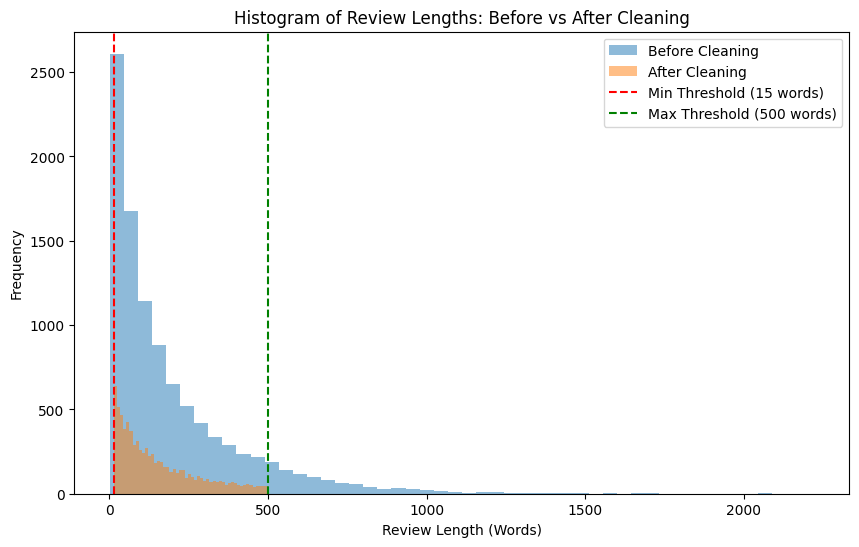

In [19]:
# Calculate lengths
reviews_raw_df['length_before'] = reviews_raw_df['review_text'].apply(lambda x: len(str(x).split()))
merged_df['length_after'] = merged_df['cleaned_review'].apply(lambda x: len(str(x).split()))

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(reviews_raw_df['length_before'], bins=50, alpha=0.5, label='Before Cleaning')
plt.hist(merged_df['length_after'], bins=50, alpha=0.5, label='After Cleaning')

# Add threshold lines for 15 and 500 words
plt.axvline(15, color='red', linestyle='--', label='Min Threshold (15 words)')
plt.axvline(500, color='green', linestyle='--', label='Max Threshold (500 words)')

plt.xlabel('Review Length (Words)')
plt.ylabel('Frequency')
plt.title('Histogram of Review Lengths: Before vs After Cleaning')
plt.legend()
plt.show()



#### Histogram of Book Description Lengths

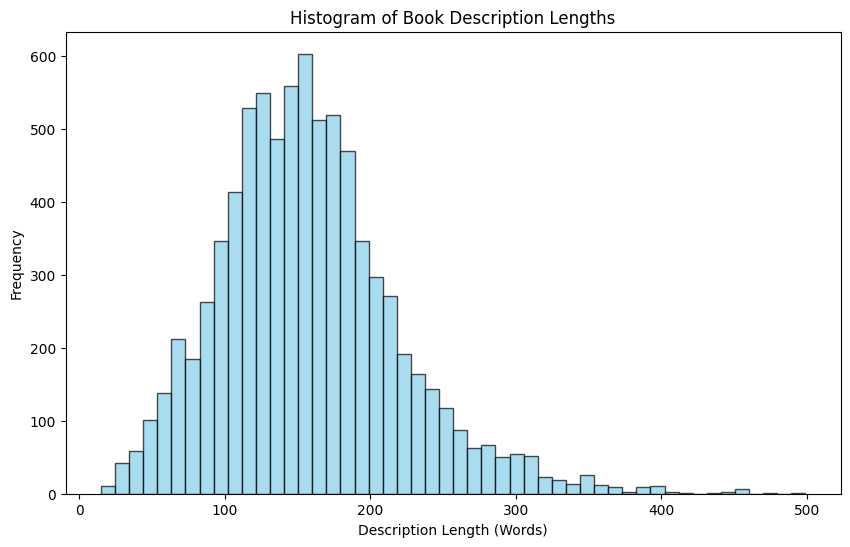

In [20]:
# Calculate description lengths
merged_df['desc_length'] = merged_df['cleaned_description'].apply(lambda x: len(str(x).split()))

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(merged_df['desc_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.xlabel('Description Length (Words)')
plt.ylabel('Frequency')
plt.title('Histogram of Book Description Lengths')
plt.show()


### Save the cleaned merged file as csv

In [21]:
# Save merged_df to CSV
merged_df.to_csv("../data/merged_df.csv", index=False, encoding="utf-8")

print("merged_df saved as merged_df.csv")


merged_df saved as merged_df.csv
